# Modelos de Classificação
- Em modelos de classificação estamos tentando prever o valor de uma categoria (banana ou maçã, fraude ou não, 0 ou 1, etc...)
- Podemos usar algortmos como Árvores de Classificação, KNN, SVM, ...
- Vamos usar novamente a base de dados do titanic.


## O Scikit-Learn
- Ferramentas simples e eficientes para análise preditiva de dados
- Acessível a todos e reutilizável em vários contextos.
- Construído em NumPy, Scipy e Matplotlib

In [1]:
import pandas as pd

# Bibliotecas de visualização
import matplotlib.pyplot as plt


# Importando modelos do SciKit-Learn
from sklearn.neighbors import KNeighborsClassifier 
from sklearn import tree
from sklearn.linear_model import LogisticRegression

# Importando Matrix de Confusão.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

# Importando acuracy score
from sklearn.metrics import accuracy_score

# Importando score de precisão
from sklearn.metrics import precision_score

# Importando o Recall Score
from sklearn.metrics import recall_score






In [2]:
df = pd.read_csv('../curso_data_science//train.csv')
display(df.head())
display(df.tail())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [287]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [288]:
# df = df.drop('Cabin', axis=1)
df = df.drop(columns=['Cabin'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [289]:
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    str    
 4   Sex          712 non-null    str    
 5   Age          712 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    str    
 9   Fare         712 non-null    float64
 10  Embarked     712 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 66.8 KB


In [290]:
# Eliminando colunas categoricas.

colunas = df.dtypes[df.dtypes.values == 'str'].index

df = df.drop(colunas, axis=1)

In [291]:
df.info()

<class 'pandas.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Age          712 non-null    float64
 4   SibSp        712 non-null    int64  
 5   Parch        712 non-null    int64  
 6   Fare         712 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 44.5 KB


In [292]:
# Separando dados para treinamento

x = df.drop('Survived', axis=1)
y = df.Survived



In [293]:
# Criando Classificador KNN

neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(x, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [294]:
# Avaliando o Modelo

neigh.score(x, y)

0.7907303370786517

## Utilizando a Árvore de Decisão


In [295]:
# Criando Classificador DecisionTree
clfArvore = tree.DecisionTreeClassifier(random_state=0)

# treinando modelo TreeDecision.
clfArvore = clfArvore.fit(x, y)
clfArvore

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples 

In [296]:
clfArvore.score(x, y)

1.0

## Logistic Regression

In [297]:
# Criando modelo de regressão e fazendo o treinamento.

clfLogistic = LogisticRegression(random_state=0, max_iter=1000).fit(x, y)

In [298]:
clfLogistic.score(x, y)

0.7064606741573034

# Avaliando Modelo de Classificação


In [299]:
df_test = pd.read_csv('train.csv')
df_test.head()
df_test = df_test.drop('Cabin', axis=1)

In [300]:
df_test.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [301]:
df_test = df_test.dropna()
colunas = df_test.dtypes[df_test.dtypes.values == 'str'].index
df_test = df_test.drop(colunas, axis=1)
df_test.info()

<class 'pandas.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Age          712 non-null    float64
 4   SibSp        712 non-null    int64  
 5   Parch        712 non-null    int64  
 6   Fare         712 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 44.5 KB


## Testando Modelos

In [302]:
# Separando dados de teste.
x_test = df_test.drop('Survived', axis=1)
y_test = df_test.Survived


In [303]:
# FAZENDO PREDIÇÃO COM KNN
pred_knn = neigh.predict(x_test)

In [304]:
# FAZENDO PREDIÇÃO COM DECISIONTREE
pred_tree = clfArvore.predict(x_test)

In [305]:
# FAZENDO PREDIÇÃO COM LOGISTIC REGRESSION
pred_log = clfLogistic.predict(x_test)

## Implementando Maxtriz de Confusão

|                     | Previsto: Positivo | Previsto: Negativo |
|---------------------|:-------------------:|:-------------------:|
| **Real: Positivo**  | VP (Verdadeiro Positivo) | FN (Falso Negativo) |
| **Real: Negativo**  | FP (Falso Positivo)      | VN (Verdadeiro Negativo) |



array([[377,  47],
       [102, 186]])

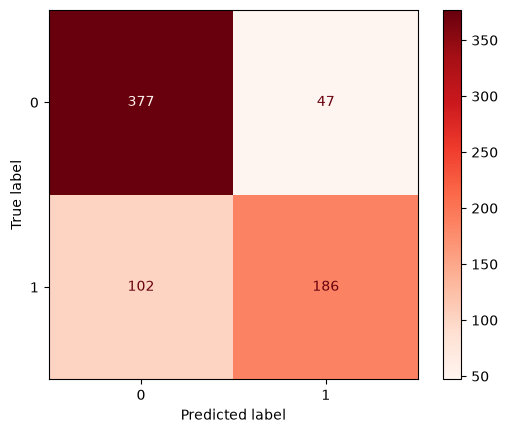

In [306]:
# Verificando a Matriz para o modelo KNN
cmKNN = confusion_matrix(y_test, pred_knn)

display(cmKNN)
ConfusionMatrixDisplay(cmKNN).plot(cmap='Reds')
plt.show()

array([[424,   0],
       [  0, 288]])

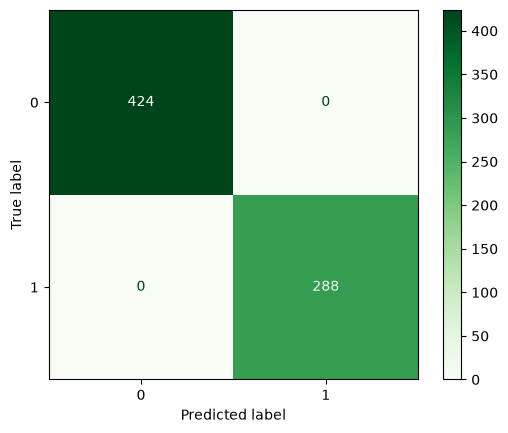

In [307]:
# Verificando a Matriz para o modelo Árvore de Decisão
cmTree = confusion_matrix(y_test, pred_tree)
display(cmTree)

ConfusionMatrixDisplay(cmTree).plot(cmap='Greens')
plt.show()

array([[355,  69],
       [140, 148]])

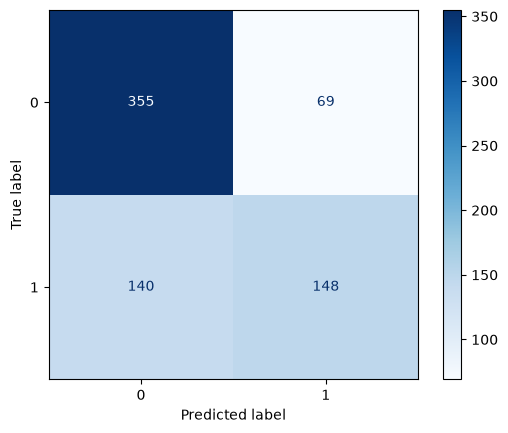

In [308]:
# Verificando a Matriz para o modelo Regressão Logistica
cmLogistic = confusion_matrix(y_test, pred_log)

display(cmLogistic)
ConfusionMatrixDisplay(cmLogistic).plot(cmap='Blues')
plt.show()


## Acurácia

Acurácia mede a proporção total de acertos do modelo, positivos e negativos juntos:
$$\text{Acurácia} = \frac{VP + VN}{VP + VN + FP + FN}$$

In [309]:
# Verificando erro de KNN
acuracia = accuracy_score(y_test, pred_knn)
acuracia

0.7907303370786517

In [310]:
# Verificando erro de Decision Tree
acuracia = accuracy_score(y_test, pred_tree)
acuracia

1.0

In [311]:
# Verificando erro de Logistic Regression
acuracia = accuracy_score(y_test, pred_log)
acuracia

0.7064606741573034

## Precisão

A precisão é o valor de verdadeiro positivo dividido pela soma do verdadeiro positivo com o falso positivo.

$$\text{Precisão} = \frac{VP}{VP + FP}$$

In [312]:
# Testando precisão dos modelos
display('Precisão KNN:',precision_score(y_test, pred_knn))
display('Precisão Árvore de Decisão:',precision_score(y_test, pred_tree))
display('Precisão Regressão Logistica:',precision_score(y_test, pred_log))

'Precisão KNN:'

0.7982832618025751

'Precisão Árvore de Decisão:'

1.0

'Precisão Regressão Logistica:'

0.6820276497695853

## Recall
Recall representa dos valores positivos o quanto consegui encontrar.
por mais que a precisão for muito boa, se o recall for baixo, não adianta.

$$\text{Recall} = \frac{VP}{VP + FN}$$

In [313]:

display('Recall do KNN', recall_score(y_test, pred_knn))
display('Recall do Árvore de Decisão', recall_score(y_test, pred_tree))
display('Recall do Regressão Logistica', recall_score(y_test, pred_log))

'Recall do KNN'

0.6458333333333334

'Recall do Árvore de Decisão'

1.0

'Recall do Regressão Logistica'

0.5138888888888888